In [1]:
import zipfile
import os

zip_path = "WikiTableQuestions-1.0.2-compact.zip"

extract_to = "WikiTableQuestions-1.0.2-compact"

os.makedirs(extract_to, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipped successfully!")


Unzipped successfully!


# Imports


In [39]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
from langdetect import detect
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords as nltk_stopwords


# Initial analysis of full train dataset

In [3]:
train_data= pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training.tagged",sep="\t")

In [4]:
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string


In [5]:
print("Nb of questions in train data: ", len(train_data))

Nb of questions in train data:  14152


## Language Detection

In [6]:

train_data["utterance_lng"]=train_data["utterance"].apply(detect)
train_data.to_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged", index=False)


In [6]:

train_data=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged")
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,True


In [11]:
res, counts = np.unique(train_data["utterance_lng"], return_counts=True)
print(res, counts)

['af' 'ca' 'cy' 'da' 'de' 'en' 'es' 'et' 'fr' 'hr' 'id' 'it' 'lv' 'nl'
 'no' 'pl' 'pt' 'sk' 'sl' 'so' 'sv' 'tl' 'tr'] [   19     4     8    10     1 14036    10     1     4     2    11     4
     1    20     3     2     1     1     1     5     1     6     1]


In [13]:
en= counts[5]*100/sum(counts)
en

99.18032786885246

Text(0, 0.5, 'Counts')

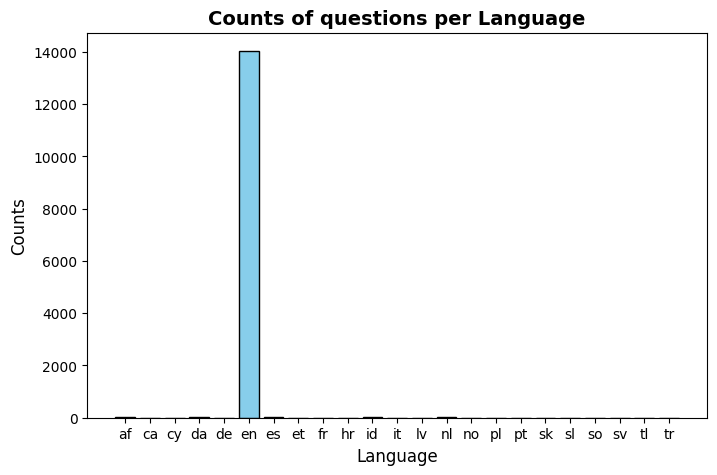

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(res, counts, color="skyblue", edgecolor="black")
plt.title("Counts of questions per Language", fontsize=14, fontweight="bold")
plt.xlabel("Language", fontsize=12)
plt.ylabel("Counts", fontsize=12)

Text(0, 0.5, 'Counts')

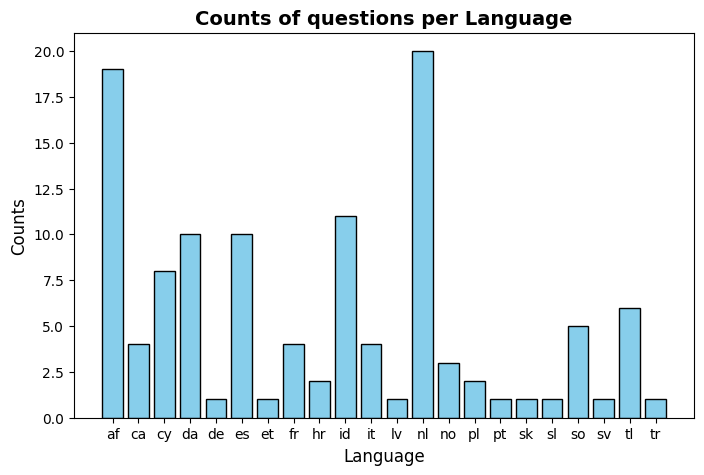

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(np.delete(res,5), np.delete(counts,5), color="skyblue", edgecolor="black")
plt.title("Counts of questions per Language", fontsize=14, fontweight="bold")
plt.xlabel("Language", fontsize=12)
plt.ylabel("Counts", fontsize=12)

In [16]:
train_data["targetCanonType"].unique()

array(['number', 'string', 'date', 'mixed', nan], dtype=object)

In [17]:
res, counts = np.unique(train_data["targetCanonType"].astype(str), return_counts=True)
print(res, counts)

['date' 'mixed' 'nan' 'number' 'string'] [ 310    8    1 6873 6960]


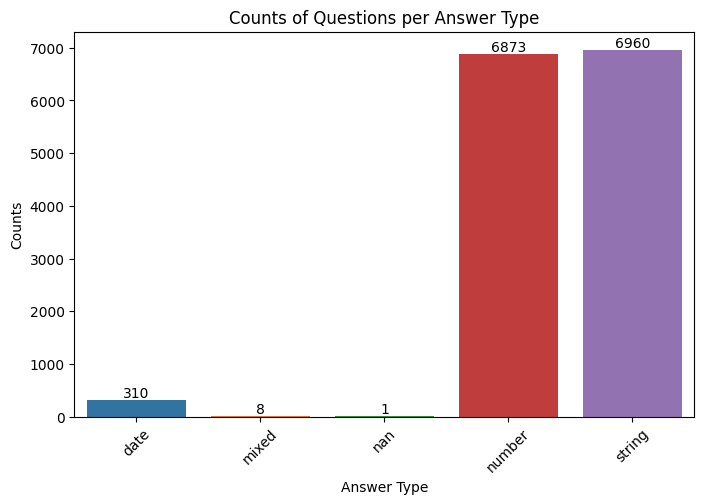

In [18]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="tab10", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of Questions per Answer Type")
plt.xlabel("Answer Type")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()

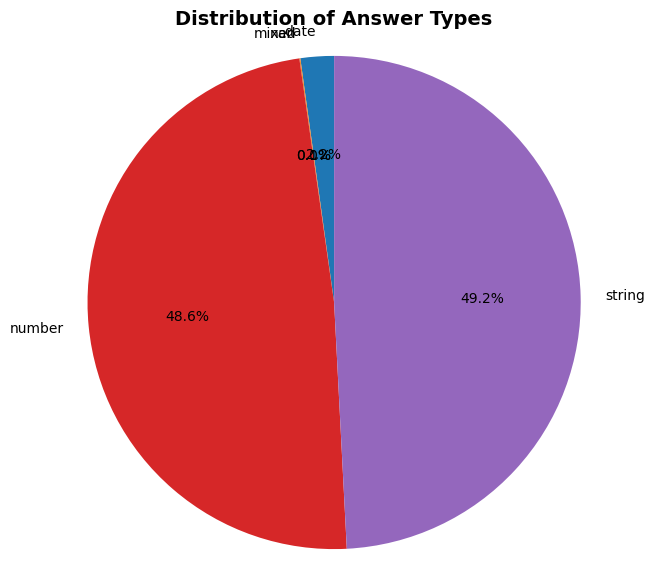

In [19]:
plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=res,
    autopct="%1.1f%%",   
    startangle=90,      
    colors=sns.color_palette("tab10", n_colors=len(res))
)
plt.title("Distribution of Answer Types", fontsize=14, fontweight="bold")
plt.axis("equal") 
plt.show()

## Topic Analysis des questions

In [31]:
# missing_rows = train_data[train_data['lemmaTokens'].isna()]
print(train_data[train_data['lemmaTokens'].isna()].index)
train_data.iloc[[12656]] #ya une errur sur ce truc


Index([12656], dtype='int64')


,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng
12656,nt-12656,what is the first track featuring lil' duval?,csv/204-csv/74.csv,Life Goes On Interlude #1\twhat|is|the|first|t...,string,NaN,NaN,NaN,NaN,NaN,NaN,en


In [33]:
#petit probleme de formattage ici, on va juste regler ca avant 
values= train_data.iloc[[12656]]["targetValue"].values[0].split("\t")
values

['Life Goes On Interlude #1',
 "what|is|the|first|track|featuring|lil|'|duval|?",
 "what|be|the|first|track|feature|lil|'|duval|?",
 "WP|VBD-AUX|DT|JJ|NN|VBG|NN|''|NNP|.",
 'O|O|O|ORDINAL|O|O|O|O|PERSON|O',
 '|||1.0||||||',
 'Life Goes On Interlude #1']

In [34]:
cols = ["targetValue", "tokens", "lemmaTokens", "posTags", "nerTags", "nerValues", "targetCanon", "targetCanonType"]
train_data.loc[12656, cols] = values + ["string"]


In [35]:
train_data.iloc[[12656]]

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng
12656,nt-12656,what is the first track featuring lil' duval?,csv/204-csv/74.csv,Life Goes On Interlude #1,what|is|the|first|track|featuring|lil|'|duval|?,what|be|the|first|track|feature|lil|'|duval|?,WP|VBD-AUX|DT|JJ|NN|VBG|NN|''|NNP|.,O|O|O|ORDINAL|O|O|O|O|PERSON|O,|||1.0||||||,Life Goes On Interlude #1,string,en


In [36]:
train_data.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged", index=False)
train_data=pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged")
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en


In [37]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
train_data["lemmaTokensJoined"]= train_data["lemmaTokens"].apply(lambda x: ' '.join(x.split('|')) if isinstance(x, str) else '')

dtm = vectorizer.fit_transform(train_data["lemmaTokensJoined"])  


In [38]:
def top_100_words(dict_count):
    most_freq=[]
    i=100
    for w,c in dict_count.items():
        if i>=0: most_freq.append((w,c))
        else:break
        i-=1
    return most_freq

In [39]:

word_counts = np.array(dtm.sum(axis=0)).flatten()
vocab = vectorizer.vocabulary_
freq_dict= {w: word_counts[idx] for w, idx in vocab.items()}
dict_count= dict(sorted(freq_dict.items(), key=lambda item: item[1],reverse=True))

print(top_100_words(dict_count))
# plt.plot(np.sort(word_counts)[::-1])

[('number', 1944), ('total', 1283), ('win', 1218), ('year', 1168), ('list', 967), ('team', 952), ('game', 903), ('time', 762), ('score', 630), ('medal', 557), ('country', 495), ('player', 493), ('play', 486), ('point', 482), ('place', 481), ('season', 408), ('chart', 386), ('finish', 346), ('difference', 337), ('release', 326), ('long', 297), ('title', 272), ('come', 270), ('date', 261), ('race', 249), ('album', 243), ('consecutive', 241), ('song', 240), ('position', 228), ('hold', 228), ('competition', 225), ('film', 221), ('people', 219), ('goal', 219), ('rank', 218), ('gold', 217), ('highest', 217), ('driver', 216), ('award', 211), ('city', 210), ('000', 208), ('population', 203), ('opponent', 202), ('party', 193), ('nation', 193), ('previous', 190), ('10', 181), ('attendance', 175), ('episode', 166), ('largest', 162), ('average', 160), ('championship', 160), ('lrb', 155), ('winner', 154), ('rrb', 154), ('table', 153), ('match', 149), ('record', 148), ('round', 146), ('vote', 142), 

In [40]:
from wordcloud import WordCloud

def draw_wordcloud(freq_dict):

  wordcloud = WordCloud(width=800, height=400, background_color='white', colormap="viridis").generate_from_frequencies(freq_dict)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title("WordCloud of questions")
  plt.axis('off')
  plt.show()

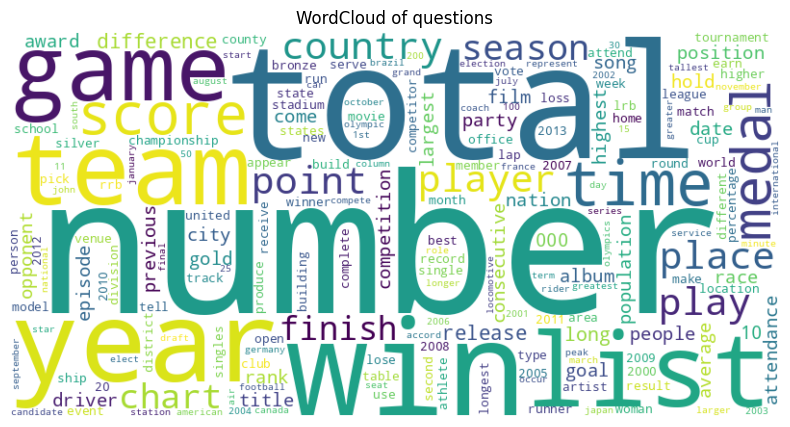

In [41]:
draw_wordcloud(dict_count)

In [51]:
num_topics = 5
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

In [67]:
def print_topics(lda, vectorizer, dict_topics= None, top_n=10): #10 tops words par topic
    words = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(lda.components_):
        
        if dict_topics: print(f"Topic {idx+1}: {dict_topics[idx+1]}") 
        else:  print(f"Topic {idx+1}:")
        print([words[i] for i in topic.argsort()[-top_n:][::-1]])
        print()




In [65]:
print_topics(lda, vectorizer)

Topic 1:
['win', 'medal', 'country', 'gold', 'nation', 'number', 'time', 'silver', 'team', 'bronze']

Topic 2:
['year', 'team', 'number', 'title', 'win', 'total', 'play', 'chart', 'album', 'release']

Topic 3:
['game', 'number', 'win', 'time', 'people', 'driver', '000', 'season', 'race', 'attendance']

Topic 4:
['place', 'finish', 'year', 'competition', 'position', 'team', 'release', 'list', 'party', 'come']

Topic 5:
['number', 'total', 'list', 'score', 'point', 'player', 'game', 'goal', 'country', 'date']



In [75]:
dict_topics = {
    1: "Global Sports Tournaments",
    2: "Music Rankings",
    3: "Races and Sporting Events",
    4: "Competitive Events",
    5: "Other"
}

In [76]:
print_topics(lda, vectorizer, dict_topics)

Topic 1: Global Sports Tournaments
['win', 'medal', 'country', 'gold', 'nation', 'number', 'time', 'silver', 'team', 'bronze']

Topic 2: Music Rankings
['year', 'team', 'number', 'title', 'win', 'total', 'play', 'chart', 'album', 'release']

Topic 3: Races and Sporting Events
['game', 'number', 'win', 'time', 'people', 'driver', '000', 'season', 'race', 'attendance']

Topic 4: Competitive Events
['place', 'finish', 'year', 'competition', 'position', 'team', 'release', 'list', 'party', 'come']

Topic 5: Other
['number', 'total', 'list', 'score', 'point', 'player', 'game', 'goal', 'country', 'date']



In [69]:
topic_dist = lda.transform(dtm)
topic_dist.shape

(14152, 5)

In [83]:
topic_question= np.argmax(topic_dist, axis=1) #nous donne a quel topic chaque question appartient

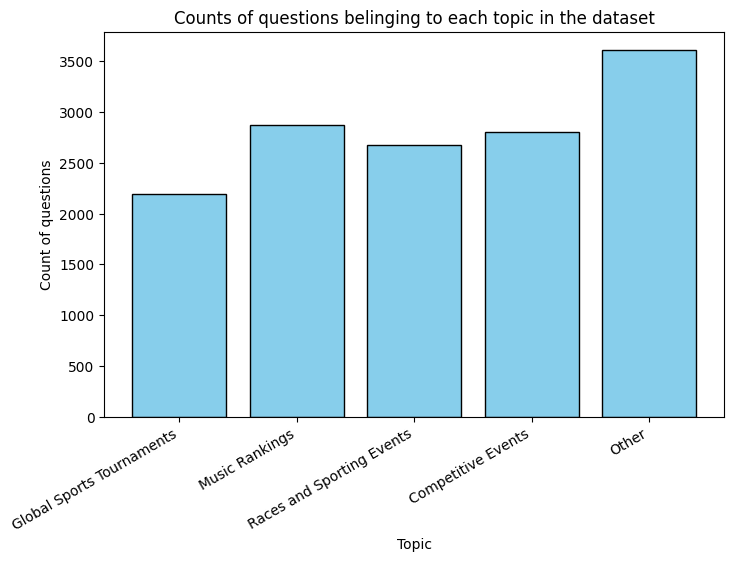

In [80]:
values, counts = np.unique(topic_question, return_counts=True)
labels = [dict_topics[v+1] for v in values]
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color='skyblue', edgecolor='black')
plt.xlabel('Topic')
plt.ylabel('Count of questions')
plt.xticks(rotation=30, ha='right')
plt.title('Counts of questions belinging to each topic in the dataset')
plt.show()

In [84]:
train_data["topic"]=topic_question
train_data.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged", index=False)
train_data=pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged")
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,lemmaTokensJoined,topic
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,what be the last year where this team be a par...,1
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,in what city do piotr 's last 1st place finish...,3
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,which team win previous to crettyard ?,3
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,how many more passenger fly to los angeles tha...,2
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,who be the opponent in the first game of the s...,2


## Analyse sur les references des colomnes dans la questions.. etc

Do column values appear in the question ? Do questions directly reference values in the table ? Is the answer directly found in the table or does it require some sort of computation ?

In [85]:

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     <local nltk data directory>...
[nltk_data]   Package stopwords is already up-to-date!


True

In [158]:
table_columns=[]
table_values=[]
column_in_question=[]
values_in_question=[]
answer_in_table=[]

for index, row in train_data.iterrows():
    try:
        table= pd.read_csv(f"WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{row['context']}")
        
    except Exception as e:
        try:
            # print("Failed , parser")
            table= pd.read_csv(f"WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{row['context'][:-4]}.table", sep="|", engine="python")
            
            
        except Exception as e2:
            X = []
            print("Failed | parser")
            with open(f"WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{row['context']}", newline='', encoding="utf-8") as f:
                
                reader = csv.reader(f, quotechar='"', escapechar='\\')
                for x in reader:
                    X.append(x)

            table = pd.DataFrame(X[1:], columns=X[0])
    
    table_c=[str(w).strip().lower() for w in table.columns]
    table_v= np.char.strip(np.char.lower(table.values.astype(str)))
    table_columns.append(table_c)
    table_values.append(table_v)
    words= row['tokens'].split('|') if isinstance(row['tokens'], str) else []
    words=[w for w in words if w.lower() not in set(nltk_stopwords.words('english'))]
    isincolumn=any(str(word).lower() in str(cell).lower() for word in words for cell in table_c)
    isinvalue=any(str(word).lower() in str(cell).lower() for word in words for cell in table_v)
    isAnswerinTable = np.any(table_v == str(row['targetValue']).strip().lower())
    column_in_question.append(isincolumn)
    values_in_question.append(isinvalue)
    answer_in_table.append(isAnswerinTable)
    # if isincolumn==False: print('*'*10,table_c,"\n", row['tokens'])


train_data['context_columns']= table_columns    #le nom des colomnes du tableau   
train_data['context_values']= table_values       #valeurs du tableau
train_data['columnInQuestion']= column_in_question   #True si la question contient un mot qu'on retrouve dans les colomnes du tableau  
train_data['valueInQuestion']= values_in_question  #True si la question contient un mot qu'on retrouve dans le tableau
train_data['answerInTable']= answer_in_table

Failed | parser


In [159]:
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,context_columns,context_values,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,"[year, division, league, regular season, playo...","[[2001, 2, usl a-league, 4th, western, quarter...",True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,"[year, competition, venue, position, event, no...","[[2001, world youth championships, debrecen, h...",True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,"[team, county, wins, years won]","[[greystones, wicklow, 1, 2011], [ballymore eu...",True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,"[rank, city, passengers, ranking, airline]","[[1, united states, los angeles, 14,749, nan, ...",False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,"[date, opponent, venue, result, attendance, sc...","[[15 august 1987, derby county, away, 0–1, 17,...",True


In [160]:
res, counts = np.unique(train_data["columnInQuestion"].astype(str), return_counts=True)
print(res, counts)

['False' 'True'] [4830 9322]


In [161]:
res, counts = np.unique(train_data["answerInTable"].astype(str), return_counts=True)
print(res, counts)

['False' 'True'] [5750 8402]


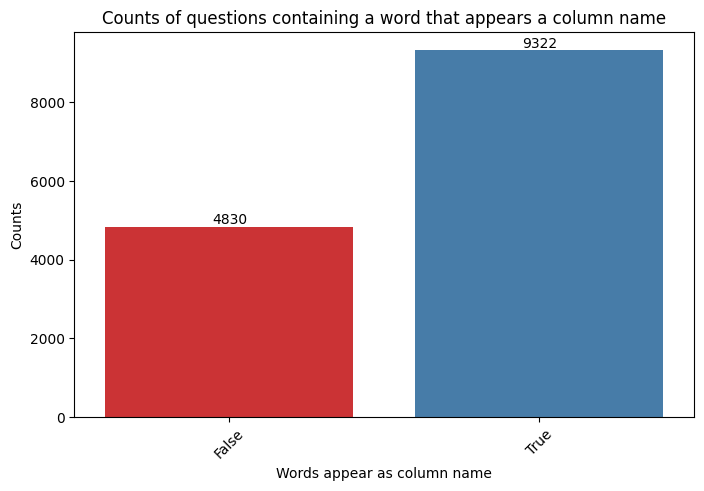

In [91]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="Set1", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of questions containing a word that appears a column name")
plt.xlabel("Words appear as column name")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()



['Requires Computation', 'Simple Lookup'] [5750 8402]


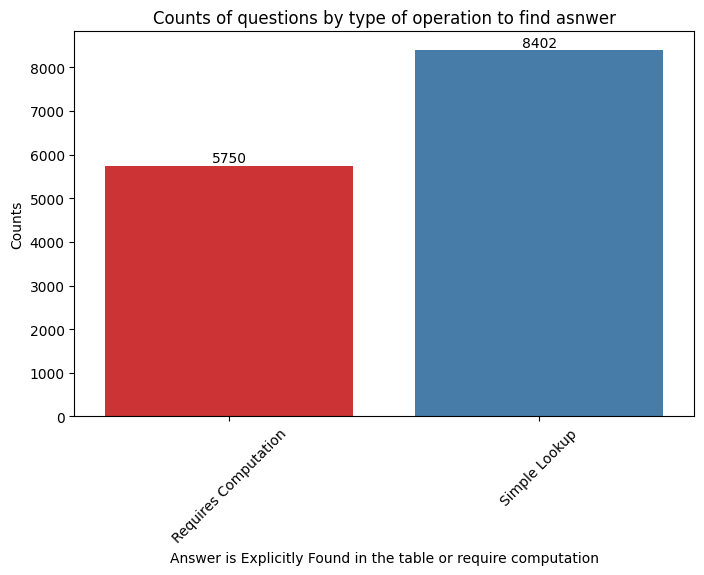

In [177]:
res, counts = np.unique(train_data["answerInTable"].astype(str), return_counts=True)
res=["Requires Computation", "Simple Lookup"]
print(res, counts)

plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="Set1", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of questions by type of operation to find asnwer")
plt.xlabel("Answer is Explicitly Found in the table or require computation")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()


In [92]:
res, counts = np.unique(train_data["valueInQuestion"].astype(str), return_counts=True)
print(res, counts)

['False' 'True'] [ 3717 10435]


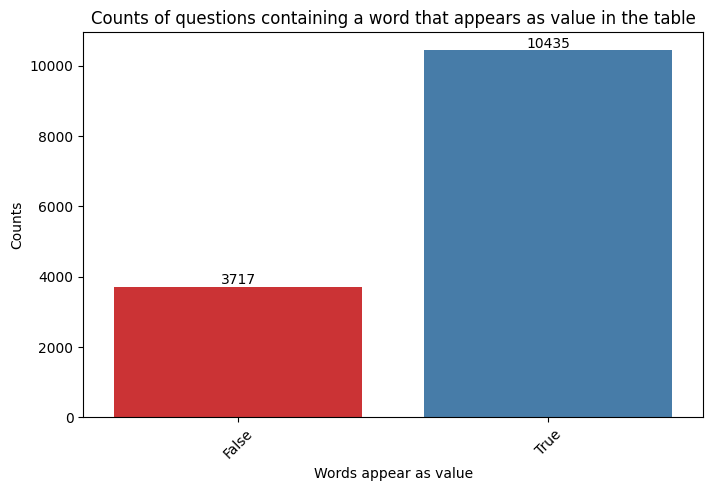

In [93]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="Set1", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of questions containing a word that appears as value in the table")
plt.xlabel("Words appear as value")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()

In [163]:
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,context_columns,context_values,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,"[year, division, league, regular season, playo...","[[2001, 2, usl a-league, 4th, western, quarter...",True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,"[year, competition, venue, position, event, no...","[[2001, world youth championships, debrecen, h...",True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,"[team, county, wins, years won]","[[greystones, wicklow, 1, 2011], [ballymore eu...",True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,"[rank, city, passengers, ranking, airline]","[[1, united states, los angeles, 14,749, nan, ...",False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,"[date, opponent, venue, result, attendance, sc...","[[15 august 1987, derby county, away, 0–1, 17,...",True


In [164]:
train_data.drop(columns=["context_columns","context_values"], inplace=True)
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,True


In [165]:
train_data.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged", index=False)
train_data=pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged")
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,True


In [166]:
len(train_data)

14152

## Anlaysis of different question types

In [148]:
def question_type(row):
    question = str(row['utterance']).lower()
    answer = str(row['targetValue']).lower()

    if 'yes' in answer or 'no' in answer:
        return "Yes/No question"

    if any(word in question for word in ["how many","how long", "how much", "count", "number of"]):
        return "Numerical question"

    if any(word in question for word in ["when", "what year", "date", "month", "day"]):
        return "Temporal question"

    if any(word in question for word in ["more than", "less than", "better"]):
        return "Comparative question"

    if any(word in question for word in ["most", "least", "best", "worst", "highest", "lowest"]):
        return "Superlative question"

    if any(word in question for word in ["what is", "who is", "where is"]):
        return "Fact question"

    if any(word in question for word in ["list", "name", "show all"]):
        return "List question"

    return "Other question"



In [149]:

train_data['question_type'] = train_data.apply(question_type, axis=1)
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question


In [150]:
train_data.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged", index=False)
train_data=pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged")
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question


## updated full training dataset


In [11]:
train_data= pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged")
train_data.head()
#Nouvelle colomnes: utterance_lng	topic	columnInQuestion	valueInQuestion	question_type	answerInTable

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,True


# ENGLISH DATASET

In [167]:
train_data_en= train_data[train_data["utterance_lng"]=='en']
print("Nb of questions is english dataset:", len(train_data_en))

print("Nb of table in english dataset:", len(train_data_en["context"].unique()))

Nb of questions is english dataset: 14036
Nb of table in english dataset: 1676


In [168]:
print("Nb of questions is full dataset:", len(train_data))

print("Nb of table in full dataset:", len(train_data["context"].unique()))
train_data_en.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged", index=False)

Nb of questions is full dataset: 14152
Nb of table in full dataset: 1679


In [169]:

train_data_en=pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")
train_data_en.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,True


## Analysis of english dataset

In [24]:
import pandas as pd
import csv
train_data_en=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")

In [16]:
train_data_en.shape

(14036, 17)

In [20]:
len(train_data_en["context"].unique()) #nb of tables

1676

In [17]:
train_data_en.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,True


In [25]:
#count of nan values per column
train_data_en.isna().sum()


id                  0
utterance           0
context             0
targetValue         1
tokens              0
lemmaTokens         0
posTags             0
nerTags             0
nerValues           0
targetCanon         1
targetCanonType     0
utterance_lng       0
topic               0
columnInQuestion    0
valueInQuestion     0
question_type       0
answerInTable       0
dtype: int64

In [22]:
# on a une row ou ces valeurs nulle existent
train_data[train_data["targetValue"].isna()]

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
10045,nt-10045,how many official guests were there on july 22...,csv/204-csv/823.csv,NaN,how|many|official|guests|were|there|on|july|22...,how|many|official|guest|be|there|on|July|22-23...,"WRB|JJ|JJ|NNS|VBD-AUX|EX|IN|NNP|CD|,|CD|.",O|O|O|O|O|O|O|DATE|DATE|DATE|DATE|O,|||||||XXXX-07|XXXX-07|XXXX-07|XXXX-07|,NaN,string,en,2,True,True,Numerical question,True


In [26]:
#on va supprimer cette row 
train_data_en.drop(train_data_en[train_data_en['id'] == 'nt-10045'].index, inplace=True)
train_data_en.isna().sum() #should be 0 now

id                  0
utterance           0
context             0
targetValue         0
tokens              0
lemmaTokens         0
posTags             0
nerTags             0
nerValues           0
targetCanon         0
targetCanonType     0
utterance_lng       0
topic               0
columnInQuestion    0
valueInQuestion     0
question_type       0
answerInTable       0
dtype: int64

In [27]:
train_data_en.to_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged", index=False)


In [30]:
train_data_en=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")
train_data_en.shape #we see we dropped 1 row

(14035, 17)

In [37]:
len(train_data_en["context"].unique()) #nb of tables

1676

In [31]:
res, counts = np.unique(train_data_en["targetCanonType"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['date' 'mixed' 'number' 'string'] [ 308    8 6825 6894] [ 2.19451372  0.05700036 48.62842893 49.120057  ]


In [32]:
res, counts = np.unique(train_data_en["topic"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['0' '1' '2' '3' '4'] [2155 2844 2651 2799 3586] [15.35447097 20.26362665 18.88849305 19.94299964 25.55040969]


In [33]:
res, counts = np.unique(train_data_en["columnInQuestion"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)


['False' 'True'] [4776 9259] [34.02921268 65.97078732]


In [34]:
res, counts = np.unique(train_data_en["valueInQuestion"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['False' 'True'] [ 3711 10324] [26.44104026 73.55895974]


In [35]:
res, counts = np.unique(train_data_en["question_type"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['Comparative question' 'Fact question' 'List question'
 'Numerical question' 'Other question' 'Superlative question'
 'Temporal question' 'Yes/No question'] [ 173 1104  562 6068 3781 1263  653  431] [ 1.2326327   7.86604916  4.00427503 43.23477022 26.93979337  8.99893124
  4.65265408  3.07089419]


In [36]:
res, counts = np.unique(train_data_en["answerInTable"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['False' 'True'] [5711 8324] [40.69112932 59.30887068]
